### Dropout and Weight Decay Implementation on Iris Dataset

#### About the Dataset: Iris Dataset

It consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters.


In [3]:
#importing libraries

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets, model_selection

In [8]:
iris_data = datasets.load_iris()
iris_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [9]:
#loading and splitting dataset into train and test sets

def read_in_and_split_data(iris_data):
    data = iris_data['data']
    target = iris_data['target']
    train_data, test_data, train_target, test_target = model_selection.train_test_split(data, target, test_size=0.1)

    return (train_data, test_data, train_target, test_target)


In [10]:
train_data, test_data, train_target, test_target = read_in_and_split_data(iris_data)

In [17]:
#model building

def get_model(input_shape):

    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.Dense(64, activation="relu", kernel_initializer="he_normal", bias_initializer="ones"),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax'),
    ])

    return model

In [18]:
model = get_model(train_data[0].shape)

In [28]:
#model compiling function

def compile_model(model):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=['accuracy']
    )

In [29]:
compile_model(model)

In [30]:
#model training

def train_model(model, train_data, train_target, epochs):

    history = model.fit(train_data, train_target, epochs=epochs, batch_size=40, validation_split=0.15)

    return history

In [31]:
history = train_model(model, train_data, train_target, epochs=800)

Epoch 1/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.2982 - loss: 1.1137 - val_accuracy: 0.4286 - val_loss: 1.0769
Epoch 2/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3070 - loss: 1.0733 - val_accuracy: 0.6190 - val_loss: 1.0580
Epoch 3/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6842 - loss: 1.0491 - val_accuracy: 0.6190 - val_loss: 1.0453
Epoch 4/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6930 - loss: 1.0286 - val_accuracy: 0.6190 - val_loss: 1.0284
Epoch 5/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6930 - loss: 1.0068 - val_accuracy: 0.6190 - val_loss: 1.0107
Epoch 6/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6930 - loss: 0.9832 - val_accuracy: 0.6190 - val_loss: 0.9906
Epoch 7/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6930 - loss: 0.9612 - val_accuracy: 0.6190 - val_loss: 0.9702
Epoch 8/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6930 - loss: 0.9401 - val_accuracy: 0.6190 - val_loss

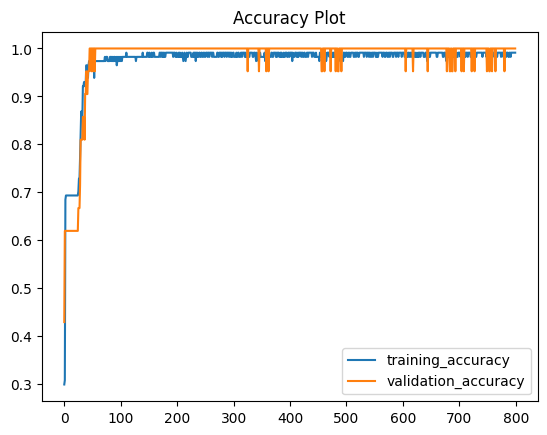

In [35]:
#accuracy visualization

plt.plot(history.history['accuracy'], label="training_accuracy")
plt.plot(history.history['val_accuracy'], label="validation_accuracy")
plt.title("Accuracy Plot")
plt.legend()
plt.show()

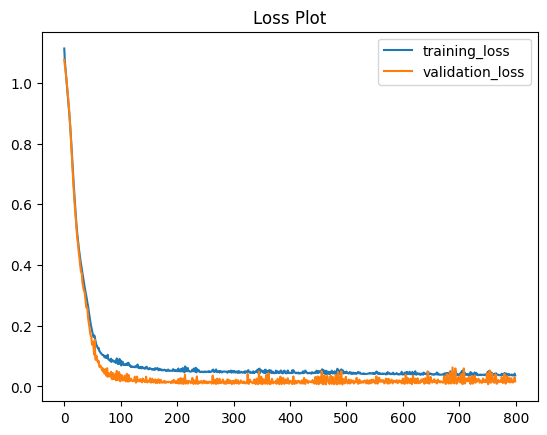

In [36]:
#loss visualization

plt.plot(history.history['loss'], label="training_loss")
plt.plot(history.history['val_loss'], label="validation_loss")
plt.title("Loss Plot")
plt.legend()
plt.show()

To reduce overfitting let's define a regularised model using dropout layers and weight decay and batch normlaization layers.

In [42]:
#regularized model function
from tensorflow.keras.regularizers import l2
def get_regularised_model(input_shape, dropout_rate, weight_decay):

    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=l2(weight_decay), kernel_initializer="he_normal", bias_initializer="ones" ),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=l2(weight_decay)),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=l2(weight_decay)),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=l2(weight_decay)),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=l2(weight_decay)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=l2(weight_decay)),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=l2(weight_decay)),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=l2(weight_decay)),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=l2(weight_decay)),
        tf.keras.layers.Dense(3, activation="softmax")
    ])

    return model

In [43]:
reg_model = get_regularised_model(train_data[0].shape, dropout_rate=0.3, weight_decay=0.001)
reg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,619 (311.01 KB)

 Trainable params: 79,363 (310.01 KB)

 Non-trainable params: 256 (1.00 KB)

#####

In [44]:
#compiling the model

compile_model(reg_model)